In [2]:
!git clone https://github.com/ZhangJUJU/OfficeCaltechDomainAdaptation

Cloning into 'OfficeCaltechDomainAdaptation'...
remote: Enumerating objects: 2581, done.
remote: Total 2581 (delta 0), reused 0 (delta 0), pack-reused 2581 (from 1)
Receiving objects: 100% (2581/2581), 72.20 MiB | 38.25 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Gradient Reversal Layer (usada en DANN y opcionalmente en CDAN)
class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_=1.0):
        ctx.lambda_ = lambda_
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None

class GradientReversalLayer(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_
    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)
import random
import numpy as np
import torch
from torchvision import models

from torchvision.models import resnet18, ResNet18_Weights,ResNet50_Weights,resnet50
class ResNetFeatureExtractor(nn.Module):
    def __init__(self, pretrained=True, output_dim=512):
        super().__init__()
        base_model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(base_model.children())[:-1])  # sin la capa FC
        self.flatten = nn.Flatten()
        self.output_dim = output_dim

    def forward(self, x):
        x = self.features(x)  # [B, 512, 1, 1]
        x = self.flatten(x)   # [B, 512]
        return x


import torch.nn as nn

class Classifier(nn.Module):
    def __init__(self, feature_dim=256, num_classes=10):
        super().__init__()
        set_seed(42)
        self.net = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class DomainDiscriminator(nn.Module):
    def __init__(self, input_dim=256):
        super().__init__()
        set_seed(42)
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.net(x)
class DANN_ResNet(nn.Module):
    def __init__(self, num_classes=10, lambda_grl=1.0):
        super().__init__()
        set_seed(42)
        self.feature = ResNetFeatureExtractor()
        self.classifier = nn.Linear(self.feature.output_dim, num_classes)
        self.domain_discriminator = DomainDiscriminator(input_dim=self.feature.output_dim)
        self.grl = GradientReversalLayer(lambda_grl)

    def forward(self, x, mode='class'):
        f = self.feature(x)
        if mode == 'class':
            return self.classifier(f)
        elif mode == 'domain':
            return self.domain_discriminator(self.grl(f))
class ADDA_ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        set_seed(42)
        self.Fs = ResNetFeatureExtractor()
        self.Ft = ResNetFeatureExtractor()
        self.classifier = nn.Linear(self.Fs.output_dim, num_classes)
        self.domain_discriminator = DomainDiscriminator(input_dim=self.Fs.output_dim)

    def forward(self, x, domain='source', mode='class'):
        if domain == 'source':
            f = self.Fs(x)
        elif domain == 'target':
            f = self.Ft(x)
        else:
            raise ValueError("domain must be 'source' or 'target'")
        if mode == 'class':
            return self.classifier(f)
        elif mode == 'domain':
            return self.domain_discriminator(f)
        else:
            raise ValueError("mode must be 'class' or 'domain'")
class CDAN_ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        set_seed(42)
        self.feature = ResNetFeatureExtractor()
        self.classifier = nn.Linear(self.feature.output_dim, num_classes)
        self.domain_discriminator = DomainDiscriminator(input_dim=self.feature.output_dim * num_classes)

    def forward(self, x, mode='class'):
        f = self.feature(x)
        y = self.classifier(f)
        if mode == 'class':
            return y
        elif mode == 'domain':
            y_soft = F.softmax(y, dim=1)
            outer = torch.bmm(y_soft.unsqueeze(2), f.unsqueeze(1)).view(x.size(0), -1)
            return self.domain_discriminator(outer)
import torch
import torch.nn as nn
import torch.nn.functional as F

class CREDA_ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        set_seed(42)
        self.feature = ResNetFeatureExtractor()
        self.classifier = nn.Linear(self.feature.output_dim, num_classes)

    def forward(self, x, mode='class'):
        f = self.feature(x)
        y = self.classifier(f)
        if mode == 'class':
            return y  # softmax se aplica externamente si es necesario
        elif mode == 'feature':
            return f

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
import torch.serialization

torch.serialization.add_safe_globals([
    ResNetFeatureExtractor,
    Classifier,
    DomainDiscriminator,
    DANN_ResNet,
    ADDA_ResNet,
    CDAN_ResNet,
    CREDA_ResNet,
    GradientReversalFunction,
    GradientReversalLayer
])
import torch

def load_model(model_type, src, tgt, path="saved_models", num_classes=10):
    model_type = model_type.lower()
    
    if model_type == "baseline":
        F = ResNetFeatureExtractor()
        C = Classifier(feature_dim=512, num_classes=num_classes)
        F.load_state_dict(torch.load(f"{path}/Baseline_{src}_{tgt}_F.pth"))
        C.load_state_dict(torch.load(f"{path}/Baseline_{src}_{tgt}_C.pth"))
        F.eval()
        C.eval()
        return F, C

    elif model_type == "dann":
        model = DANN_ResNet(num_classes=num_classes)
        model.load_state_dict(torch.load(f"{path}/DANN_{src}_{tgt}_weights.pth"))
        model.eval()
        return model

    elif model_type == "adda":
        model = ADDA_ResNet(num_classes=num_classes)
        model.load_state_dict(torch.load(f"{path}/ADDA_{src}_{tgt}_weights.pth"))
        model.eval()
        return model

    elif model_type == "cdan":
        model = CDAN_ResNet(num_classes=num_classes)
        model.load_state_dict(torch.load(f"{path}/CDAN_{src}_{tgt}_weights.pth"))
        model.eval()
        return model

    elif model_type == "creda":
        model = CREDA_ResNet(num_classes=num_classes)
        model.load_state_dict(torch.load(f"{path}/CREDA_{src}_{tgt}_weights.pth"))
        model.eval()
        return model

    else:
        raise ValueError(f"Modelo no reconocido: {model_type}")
# Función adaptada para extraer features de cualquier modelo
def extract_features_adaptive(model, dataloader, domain="source", device="cuda"):
    model.eval()
    features = []
    labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            if isinstance(model, ADDA_ResNet):
                f = model.Fs(x) if domain == "source" else model.Ft(x)
            else:
                f = model.feature(x)
            features.append(f.cpu())
            labels.append(y)

    return torch.cat(features), torch.cat(labels)
def extract_features_baseline(F, dataloader, device="cuda"):
    F.eval()
    features = []
    labels = []

    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            feats = F(x)
            features.append(feats.cpu())
            labels.append(y)

    return torch.cat(features), torch.cat(labels)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from itertools import permutations
from tqdm import tqdm
import numpy as np
import pandas as pd
# --- División estratificada común ---
def split_stratified(dataset, val_ratio=0.2, test_ratio=None, seed=42):
    set_seed(42)
    if hasattr(dataset, "targets"):
        labels = np.array(dataset.targets)
    elif hasattr(dataset, "labels"):
        labels = np.array(dataset.labels)
    else:
        raise ValueError("El dataset no tiene 'targets' ni 'labels'.")

    indices = np.arange(len(dataset))
    if test_ratio is None:
        sss = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
        train_idx, val_idx = next(sss.split(indices, labels))
        return Subset(dataset, train_idx), Subset(dataset, val_idx)
    else:
        sss1 = StratifiedShuffleSplit(n_splits=1, test_size=val_ratio + test_ratio, random_state=seed)
        train_idx, temp_idx = next(sss1.split(indices, labels))
        temp_labels = labels[temp_idx]
        sss2 = StratifiedShuffleSplit(n_splits=1, test_size=test_ratio / (val_ratio + test_ratio), random_state=seed)
        val_idx, test_idx = next(sss2.split(temp_idx, temp_labels))
        val_idx = temp_idx[val_idx]
        test_idx = temp_idx[test_idx]
        return Subset(dataset, train_idx), Subset(dataset, val_idx), Subset(dataset, test_idx)

In [6]:
!pip install -q gdown

# Descargar directamente desde el enlace de Google Drive (ID del archivo)
!gdown --id 1G0x-arLRPuE-IKDfkxSa-bvPMltvYVsf -O ImageCLEF-DA.zip

import zipfile
import os

zip_path = "ImageCLEF-DA.zip"
extract_dir = "ImageCLEF-DA"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Verificar contenido
os.listdir(extract_dir)


/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1G0x-arLRPuE-IKDfkxSa-bvPMltvYVsf
From (redirected): https://drive.google.com/uc?id=1G0x-arLRPuE-IKDfkxSa-bvPMltvYVsf&confirm=t&uuid=35a1c96e-703f-4907-be48-675ec31cef59
To: /kaggle/working/ImageCLEF-DA.zip
100%|█████████████████████████████████████████| 225M/225M [00:01<00:00, 115MB/s]


['image_CLEF']

In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision import transforms

set_seed(42)
# Transforms
transform_digits = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

transform_clef = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Dataset loading
mnist_full = datasets.MNIST(root='.', train=True, download=True, transform=transform_digits)
usps_full = datasets.USPS(root='.', train=True, download=True, transform=transform_digits)
svhn_full = datasets.SVHN(root='.', split='train', download=True, transform=transform_digits)

I_full = ImageFolder("/kaggle/working/ImageCLEF-DA/image_CLEF/i", transform=transform_clef)
P_full = ImageFolder("/kaggle/working/ImageCLEF-DA/image_CLEF/p", transform=transform_clef)
C_full = ImageFolder("/kaggle/working/ImageCLEF-DA/image_CLEF/c", transform=transform_clef)

A_full = ImageFolder("/kaggle/working/OfficeCaltechDomainAdaptation/images/amazon", transform=transform_clef)
W_full = ImageFolder("/kaggle/working/OfficeCaltechDomainAdaptation/images/webcam", transform=transform_clef)
D_full = ImageFolder("/kaggle/working/OfficeCaltechDomainAdaptation/images/dslr", transform=transform_clef)

# Agrupación
set_1 = {"M": mnist_full, "U": usps_full, "S": svhn_full}
set_2 = {"I": I_full, "P": P_full, "C": C_full}
set_3 = {"A": A_full, "W": W_full, "D": D_full}
sets_all = {
    "MNIST-USPS-SVHN": set_1,
    "ImageCLEF": set_2,
    "Office-Caltech": set_3
}
combinations_dict = {
    "MNIST-USPS-SVHN": ("M", "U"),  # MNIST → USPS
    "ImageCLEF": ("P", "C"),        # Imagenet → Photo
    "Office-Caltech": ("W", "D")    # Webcam → DSLR
}

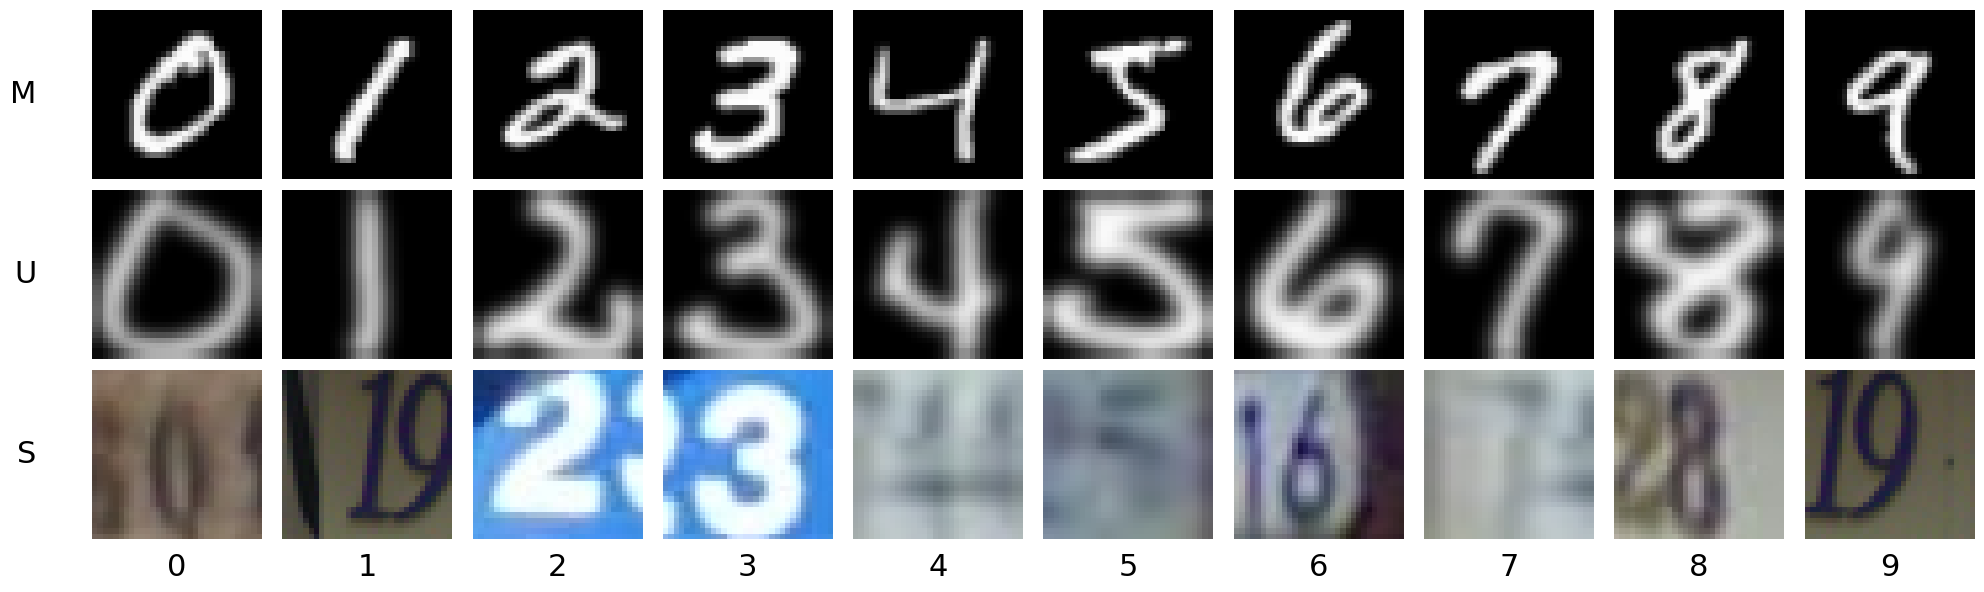

In [23]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from torchvision import datasets, transforms
from torchvision.transforms.functional import to_pil_image
from skimage.transform import resize

# -----------------------------
# CONFIGURACIÓN
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
selected_classes = list(range(10))
domains = ["M", "U", "S"]

# Cargar datasets sin transformaciones
mnist_raw = datasets.MNIST(root='.', train=True, download=True)
usps_raw = datasets.USPS(root='.', train=True, download=True)
svhn_raw = datasets.SVHN(root='.', split='train', download=True)

datasets_digits = [mnist_raw, usps_raw, svhn_raw]

# -----------------------------
# FUNCIÓN: Obtener una muestra por clase
# -----------------------------
def get_one_sample_per_selected_classes(dataset, class_list):
    samples = []
    found = {cls: False for cls in class_list}
    for i in range(len(dataset)):
        x, y = dataset[i]
        y_int = int(y)
        if y_int in class_list and not found[y_int]:
            samples.append((class_list.index(y_int), x))
            found[y_int] = True
        if all(found.values()):
            break
    return [x for _, x in sorted(samples, key=lambda x: x[0])]

# -----------------------------
# FUNCIÓN: Convertir imagen a array RGB visualizable
# -----------------------------
def tensor_to_imgarray(image, target_shape=(32, 32)):
    if not torch.is_tensor(image):
        img_rgb = np.array(image.convert("RGB"))
    else:
        tensor = image.clone().cpu().clamp(0, 1)
        img_pil = to_pil_image(tensor)
        img_rgb = np.array(img_pil.convert("RGB"))
    
    resized = resize(img_rgb, target_shape, preserve_range=True, anti_aliasing=True).astype(np.uint8)
    return resized

# -----------------------------
# VISUALIZACIÓN FINAL CON LABELS ABAJO
# -----------------------------
def show_digit_domains_grid(domains, datasets, class_list):
    n_rows, n_cols = len(domains), len(class_list)
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))

    for row_idx, (domain, dataset) in enumerate(zip(domains, datasets)):
        samples = get_one_sample_per_selected_classes(dataset, class_list)
        for col_idx, img in enumerate(samples):
            img_array = tensor_to_imgarray(img, target_shape=(32, 32))
            ax = axs[row_idx, col_idx]
            ax.imshow(img_array)

            # Ocultar ticks y bordes sin desactivar el eje
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_frame_on(False)

            # Etiquetas de fila (izquierda)
            if col_idx == 0:
                ax.annotate(domain, xy=(0, 0.5), xytext=(-40, 0),
                            xycoords='axes fraction', textcoords='offset points',
                            size=22, ha='right', va='center')

            # Etiquetas de columna (abajo)
            if row_idx == n_rows - 1:
                ax.set_xlabel(f"{class_list[col_idx]}", fontsize=22, labelpad=10)

    plt.tight_layout()
    plt.savefig("digits.pdf", format="pdf", bbox_inches="tight")
    plt.show()
# -----------------------------
# EJECUCIÓN
# -----------------------------
show_digit_domains_grid(domains, datasets_digits, selected_classes)


In [20]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import ImageFolder
from skimage.transform import resize
import os

# -----------------------------
# FUNCIÓN: Obtener una imagen por clase (PIL)
# -----------------------------
def get_representative_per_class(dataset):
    class_to_img = {}
    for path, label in dataset.samples:
        if label not in class_to_img:
            img = dataset.loader(path)
            class_to_img[label] = img
        if len(class_to_img) == len(dataset.classes):
            break
    return [class_to_img[i] for i in range(len(dataset.classes))]

# -----------------------------
# FUNCIÓN: Convertir imagen PIL → np.array RGB redimensionado
# -----------------------------
def pil_to_imgarray(pil_image, target_shape=(64, 64)):
    img_rgb = np.array(pil_image.convert("RGB"))
    resized = resize(img_rgb, target_shape, preserve_range=True, anti_aliasing=True).astype(np.uint8)
    return resized

# -----------------------------
# VISUALIZACIÓN GENERAL
# -----------------------------
def show_multi_domain_class_grid(domains_dict, target_shape=(64, 64), title=""):
    domain_names = list(domains_dict.keys())
    n_domains = len(domain_names)
    
    # Asumimos que todas tienen las mismas clases (mismo orden)
    example_dataset = list(domains_dict.values())[0]
    class_names = example_dataset.classes
    n_classes = len(class_names)

    fig, axs = plt.subplots(n_domains, n_classes, figsize=(n_classes * 2, n_domains * 2.5))

    for row_idx, domain in enumerate(domain_names):
        dataset = domains_dict[domain]
        samples = get_representative_per_class(dataset)

        for col_idx in range(n_classes):
            ax = axs[row_idx, col_idx] if n_domains > 1 else axs[col_idx]
            img_array = pil_to_imgarray(samples[col_idx], target_shape)
            ax.imshow(img_array)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_frame_on(False)

            # Nombre del dominio (etiqueta de fila)
            if col_idx == 0:
                ax.annotate(domain, xy=(0, 0.5), xytext=(-40, 0),
                            xycoords='axes fraction', textcoords='offset points',
                            size=22, ha='right', va='center')

            # Nombre de la clase (etiqueta de columna)
            if row_idx == n_domains - 1:
                ax.set_xlabel(class_names[col_idx], fontsize=22, rotation=0, labelpad=10, ha='center')

    plt.tight_layout()
    #if title:
    #    plt.suptitle(title, fontsize=16, y=1.02)
    plt.savefig(f"{title.lower().replace(' ', '_')}_grid.pdf", format="pdf", bbox_inches="tight")
    plt.show()


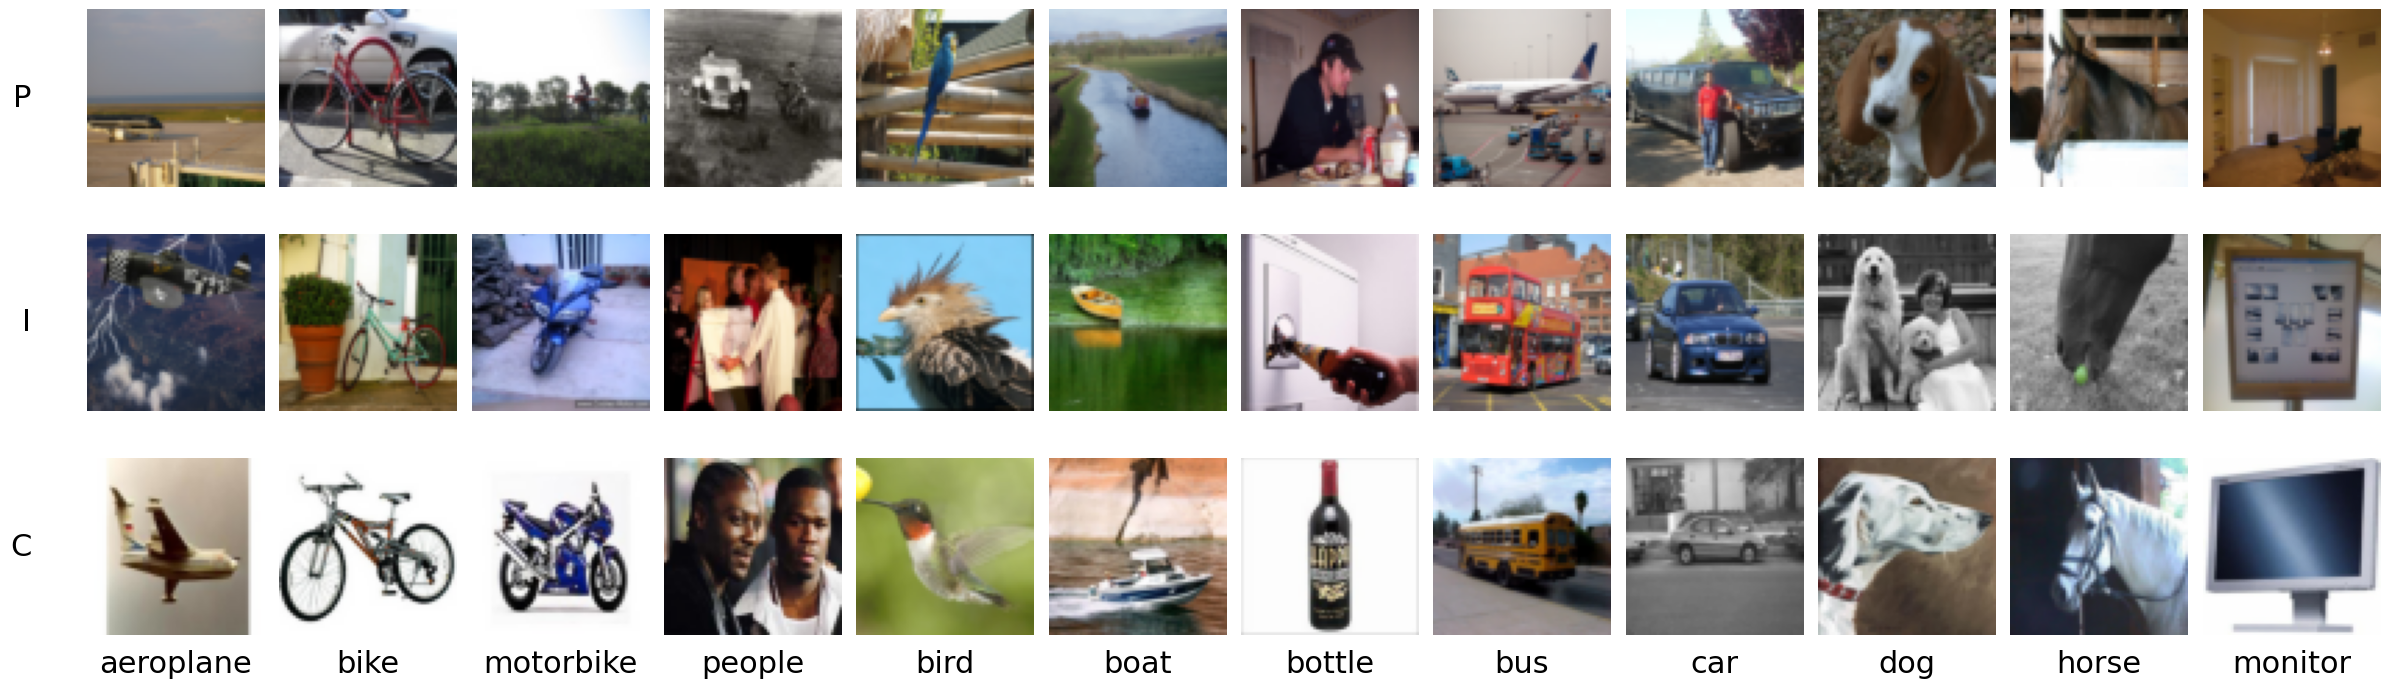

In [21]:
folder_name_to_class = {
    "1": "aeroplane",
    "2": "bike",
    "3": "bird",
    "4": "boat",
    "5": "bottle",
    "6": "bus",
    "7": "car",
    "8": "dog",
    "9": "horse",
    "10": "monitor",
    "11": "motorbike",
    "12": "people"
}
from torchvision.datasets import ImageFolder

clef_paths = {
    "P": "/kaggle/working/ImageCLEF-DA/image_CLEF/p",
    "I": "/kaggle/working/ImageCLEF-DA/image_CLEF/i",
    "C": "/kaggle/working/ImageCLEF-DA/image_CLEF/c"
}

folder_name_to_class = {
    "0": "aeroplane",
    "1": "bike",
    "2": "bird",
    "3": "boat",
    "4": "bottle",
    "5": "bus",
    "6": "car",
    "7": "dog",
    "8": "horse",
    "9": "monitor",
    "10": "motorbike",
    "11": "people"
}

clef_datasets = {}
for k, v in clef_paths.items():
    ds = ImageFolder(v)
    # Orden real en que ImageFolder ve las carpetas (alfabéticamente)
    folder_order = ds.classes  # e.g., ['1', '10', '11', ..., '9']
    ds.classes = [folder_name_to_class[c] for c in folder_order]
    clef_datasets[k] = ds

# Visualización corregida
show_multi_domain_class_grid(clef_datasets, title="imageclef")


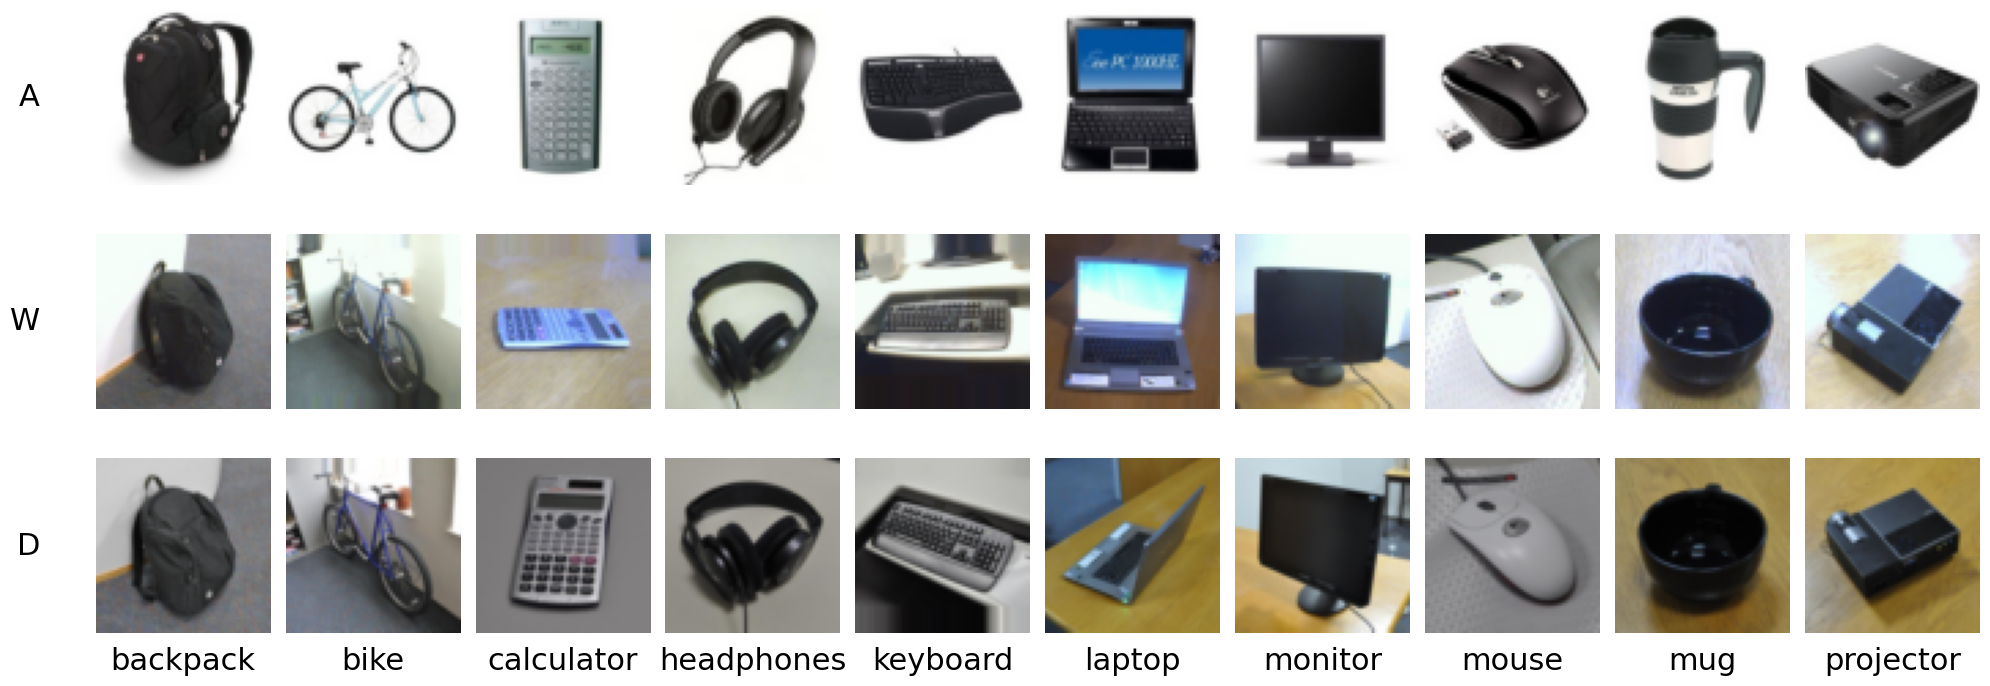

In [22]:
office_paths = {
    "A": "/kaggle/working/OfficeCaltechDomainAdaptation/images/amazon",
    "W": "/kaggle/working/OfficeCaltechDomainAdaptation/images/webcam",
    "D": "/kaggle/working/OfficeCaltechDomainAdaptation/images/dslr"
}

office_datasets = {k: ImageFolder(v) for k, v in office_paths.items()}
show_multi_domain_class_grid(office_datasets, title="office")


In [ ]:
#####################################
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import numpy as np
from cuml.manifold.umap import UMAP as cuUMAP
from sklearn.preprocessing import MinMaxScaler
from torchvision.transforms.functional import to_pil_image
from torch.utils.data import ConcatDataset, DataLoader
from skimage.transform import resize
import torch

# Configuración
model_names = ["baseline", "dann", "adda", "cdan", "creda"]
dataset_names = ["MNIST-USPS-SVHN", "ImageCLEF", "Office-Caltech"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cmap_binary = mpl.colors.ListedColormap(["#ff7f0e", "#1f77b4"])

# Diccionario global
creda_results = {}

# Función de resize PIL → np.array (28x28x3)
def resize_image_pil(img, target_shape=(28, 28)):
    img = np.array(img.convert("RGB"))
    resized_img = resize(img, target_shape, preserve_range=True, anti_aliasing=True).astype(np.uint8)
    return resized_img

# Figura
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(25, 15))
fig.subplots_adjust(hspace=0, wspace=0)

# Proceso
for row_idx, dataset_key in enumerate(dataset_names):
    sets_dict = sets_all[dataset_key]
    src, tgt = combinations_dict[dataset_key]
    src_data = sets_dict[src]
    tgt_data = sets_dict[tgt]

    src_train, src_val, src_test = split_stratified(src_data, 0.15, 0.15)
    tgt_train, tgt_val, tgt_test = split_stratified(tgt_data, 0.15, 0.15)
    src_test = ConcatDataset([src_val, src_test])
    tgt_test = ConcatDataset([tgt_val, tgt_test])

    src_loader = DataLoader(src_test, batch_size=64, shuffle=False)
    tgt_loader = DataLoader(tgt_test, batch_size=64, shuffle=False)

    targets = src_data.targets if hasattr(src_data, 'targets') else src_data.labels
    num_classes = len(set(targets.tolist() if hasattr(targets, 'tolist') else list(targets)))

    for col_idx, model_name in enumerate(model_names):
        ax = axes[row_idx, col_idx]

        try:
            if model_name == "baseline":
                F, _ = load_model(model_name, src, tgt, path="/kaggle/input/model-ad/Models", num_classes=num_classes)
                F = F.to(device)
                features_src, _ = extract_features_baseline(F, src_loader, device)
                features_tgt, _ = extract_features_baseline(F, tgt_loader, device)
            else:
                model = load_model(model_name, src, tgt, path="/kaggle/input/model-ad/Models", num_classes=num_classes)
                model = model.to(device)
                features_src, labels_src = extract_features_adaptive(model, src_loader, domain="source", device=device)
                features_tgt, labels_tgt = extract_features_adaptive(model, tgt_loader, domain="target", device=device)

            features = np.concatenate([features_src, features_tgt], axis=0)
            is_source = np.array([1]*len(features_src) + [0]*len(features_tgt))

            reducer = cuUMAP(n_components=2, n_neighbors=80, random_state=42)
            X_scaled = MinMaxScaler().fit_transform(features)
            Z = MinMaxScaler().fit_transform(reducer.fit_transform(X_scaled))

            ax.set_facecolor("white")
            ax.scatter(Z[:, 0], Z[:, 1], c=is_source, cmap=cmap_binary, s=10, alpha=0.6)
            ax.axis("off")

            rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                     linewidth=2, edgecolor='black', facecolor='none')
            ax.add_patch(rect)

            if model_name == "creda":
                
                
                
                def get_denormalizer(dataset_key):
                    if dataset_key == "MNIST-USPS-SVHN":
                        mean, std = [0.5]*3, [0.5]*3
                    else:
                        mean = [0.485, 0.456, 0.406]
                        std  = [0.229, 0.224, 0.225]
                    def denorm(t):
                        for ch, m, s in zip(t, mean, std):
                            ch.mul_(s).add_(m)
                        return t.clamp(0, 1)
                    return denorm
                
                # Dentro del bucle de dataset_key
                denormalize = get_denormalizer(dataset_key)
                imgs_src = [resize_image_pil(to_pil_image(denormalize(x[0].clone().cpu()))) for x in src_test]
                imgs_tgt = [resize_image_pil(to_pil_image(denormalize(x[0].clone().cpu()))) for x in tgt_test]

                imgs = np.concatenate([imgs_src, imgs_tgt], axis=0)
                labels_all = np.concatenate([labels_src, labels_tgt])
                creda_results[dataset_key] = {
                    "Z": Z,
                    "is_source": is_source,
                    "labels_all": labels_all,
                    "imgs": imgs,
                    "num_classes": num_classes
                }

        except Exception as e:
            ax.set_title(f"{model_name.upper()} Failed", fontsize=10, color="red")
            ax.axis("off")
            print(f"[Error] {model_name.upper()} ({src}->{tgt}): {e}")

# Etiquetas
row_labels = ["M→U", "P→C", "W→D"]
for ax, row_label in zip(axes[:, 0], row_labels):
    ax.annotate(row_label, xy=(0, 0.5), xytext=(-50, 0),
                xycoords='axes fraction', textcoords='offset points',
                size=20, ha='right', va='center', rotation=90)

model_names = ["Baseline", "DANN", "ADDA", "CDAN+E", "CRERDA"]
for col_idx, model_name in enumerate(model_names):
    ax = axes[-1, col_idx]
    ax.text(0.5, -0.15, model_name, transform=ax.transAxes,
            ha='center', va='center', fontsize=20)

plt.tight_layout(rect=[0.08, 0.03, 0.99, 0.95])
plt.savefig("umap_projection.pdf", format="pdf", bbox_inches="tight")
plt.show()


[2025-07-02 15:28:48.885] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-07-02 15:28:58.904] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-07-02 15:29:09.193] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-07-02 15:29:19.160] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-07-02 15:29:29.016] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-07-02 15:29:53.005] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-07-02 15:29:55.162] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-07-02 15:29:57.589] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-07-02 15:29:59.787] [CUML] [info] build_algo set to brute_force_knn because random_state is given
[2025-07-02 15:30:01.972] [CUML] [info] build_algo set to brute_

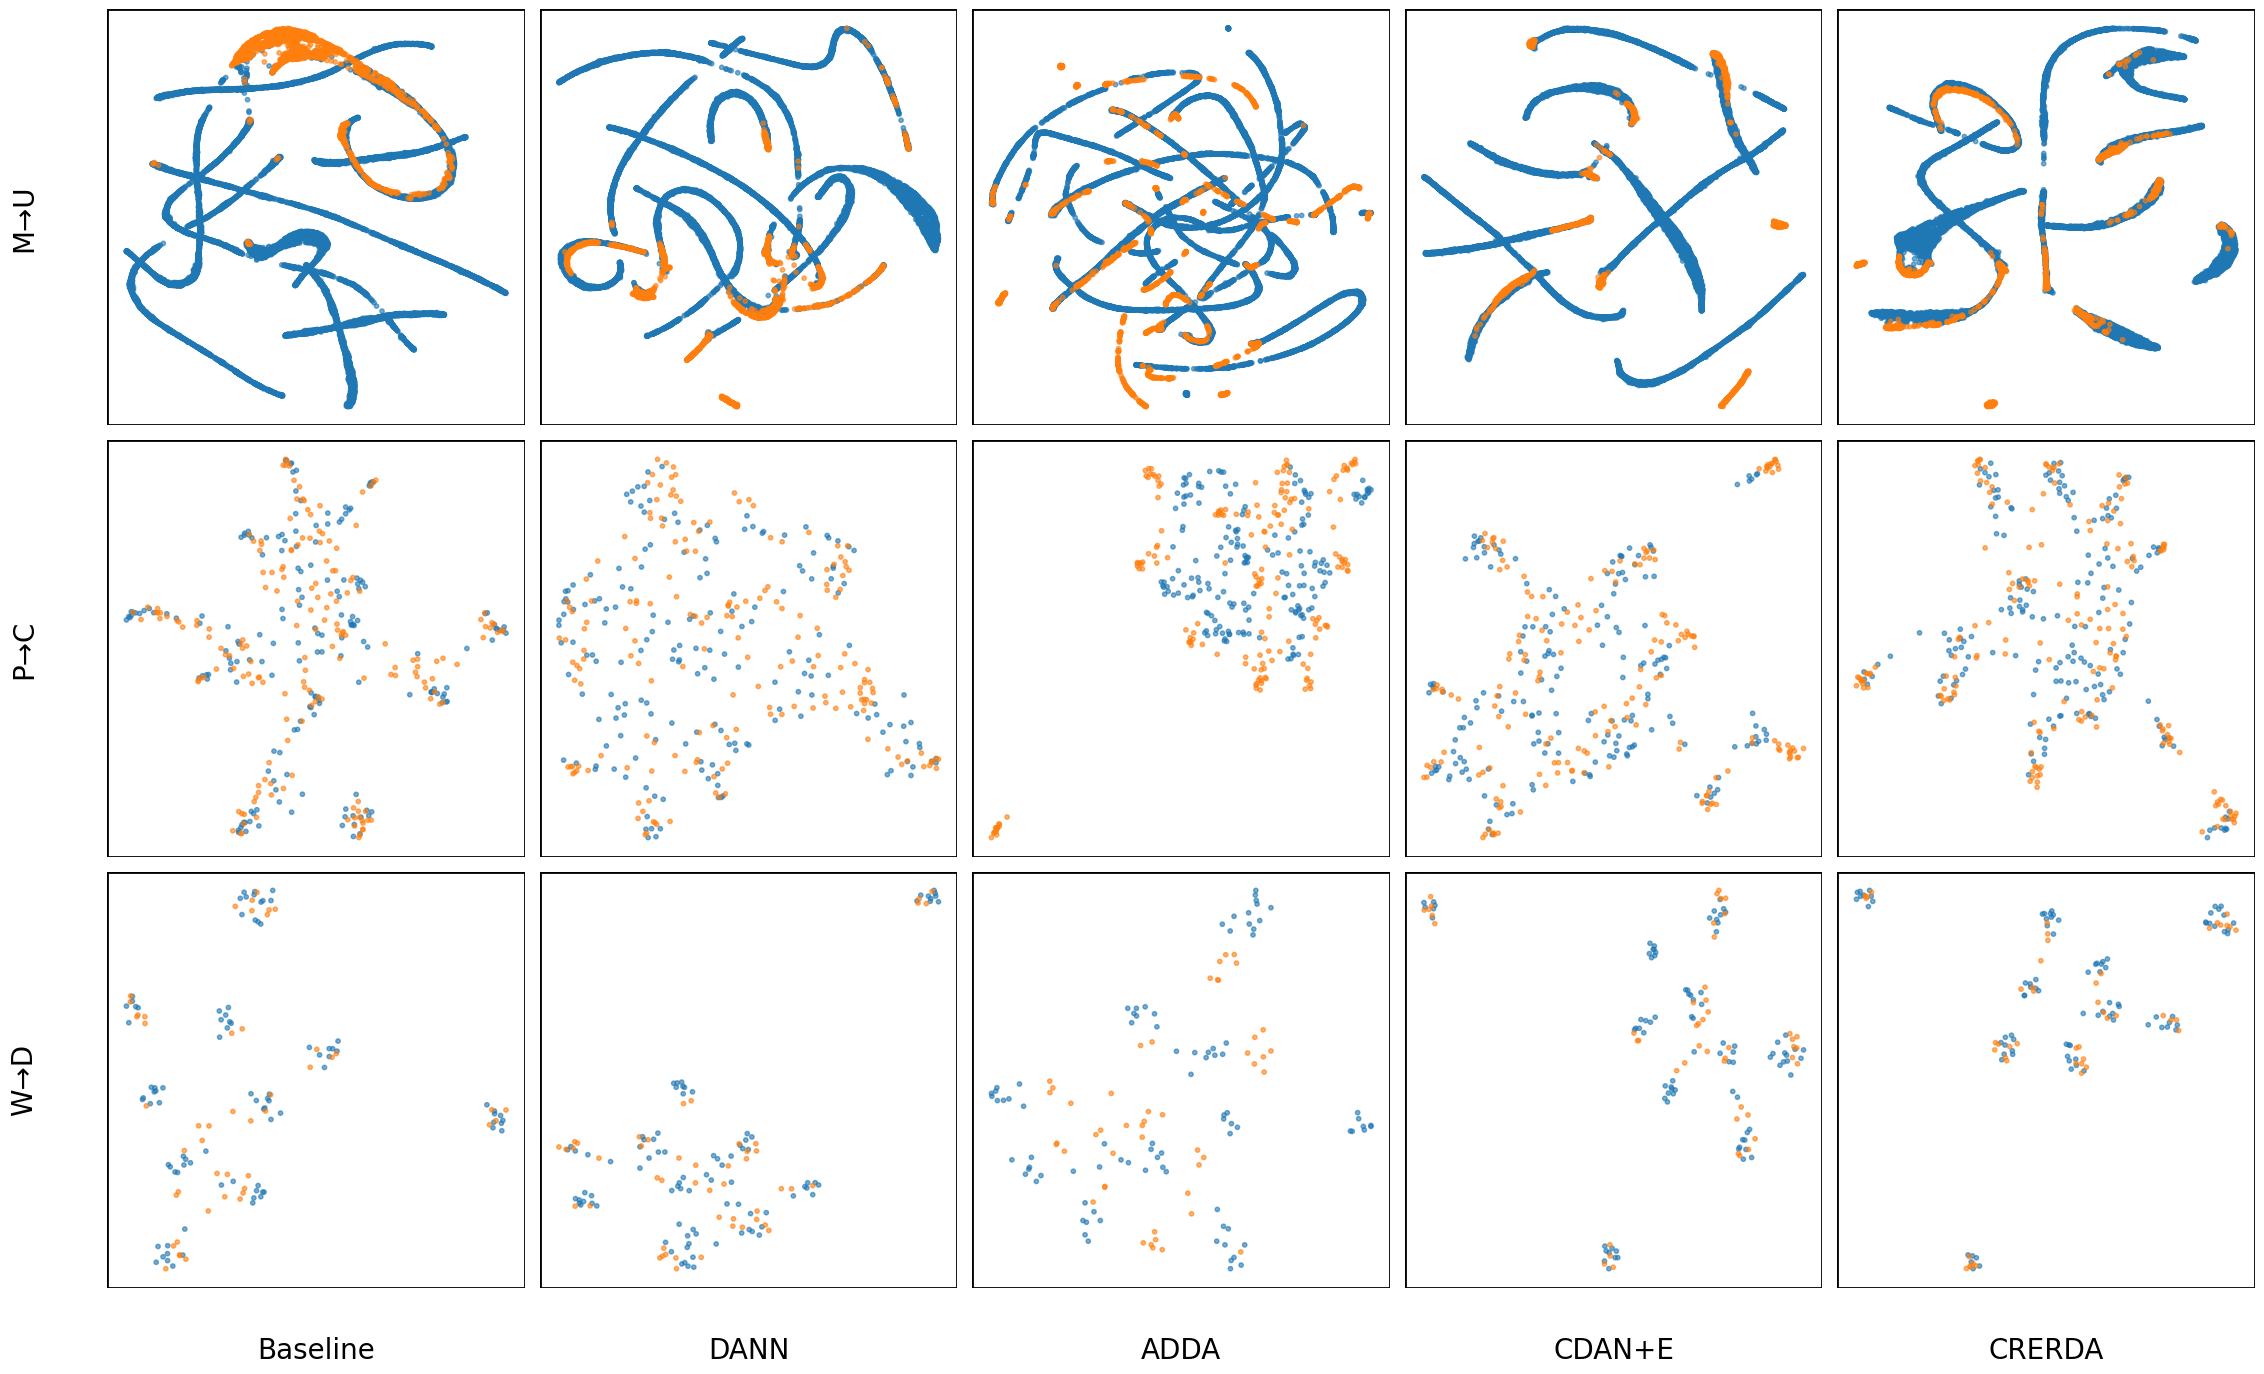

In [29]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import numpy as np
from cuml.manifold.umap import UMAP as cuUMAP
from sklearn.preprocessing import MinMaxScaler
from torchvision.transforms.functional import to_pil_image
from torch.utils.data import ConcatDataset, DataLoader
from skimage.transform import resize
import torch

# Configuración
model_names = ["baseline", "dann", "adda", "cdan", "creda"]
dataset_names = ["MNIST-USPS-SVHN", "ImageCLEF", "Office-Caltech"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cmap_binary = mpl.colors.ListedColormap(["#ff7f0e", "#1f77b4"])

# Diccionario global
creda_results = {}

# Función de resize PIL → np.array (28x28x3)
def resize_image_pil(img, target_shape=(28, 28)):
    img = np.array(img.convert("RGB"))
    resized_img = resize(img, target_shape, preserve_range=True, anti_aliasing=True).astype(np.uint8)
    return resized_img

# Figura
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(25, 15))
fig.subplots_adjust(hspace=0, wspace=0)

# Proceso
for row_idx, dataset_key in enumerate(dataset_names):
    sets_dict = sets_all[dataset_key]
    src, tgt = combinations_dict[dataset_key]
    src_data = sets_dict[src]
    tgt_data = sets_dict[tgt]

    src_train, src_val, src_test = split_stratified(src_data, 0.15, 0.15)
    tgt_train, tgt_val, tgt_test = split_stratified(tgt_data, 0.15, 0.15)
    src_test = ConcatDataset([src_val, src_test])
    tgt_test = ConcatDataset([tgt_val, tgt_test])

    src_loader = DataLoader(src_test, batch_size=64, shuffle=False)
    tgt_loader = DataLoader(tgt_test, batch_size=64, shuffle=False)

    targets = src_data.targets if hasattr(src_data, 'targets') else src_data.labels
    num_classes = len(set(targets.tolist() if hasattr(targets, 'tolist') else list(targets)))

    for col_idx, model_name in enumerate(model_names):
        ax = axes[row_idx, col_idx]

        try:
            if model_name == "baseline":
                F, _ = load_model(model_name, src, tgt, path="/kaggle/input/model-ad/Models", num_classes=num_classes)
                F = F.to(device)
                features_src, _ = extract_features_baseline(F, src_loader, device)
                features_tgt, _ = extract_features_baseline(F, tgt_loader, device)
            else:
                model = load_model(model_name, src, tgt, path="/kaggle/input/model-ad/Models", num_classes=num_classes)
                model = model.to(device)
                features_src, labels_src = extract_features_adaptive(model, src_loader, domain="source", device=device)
                features_tgt, labels_tgt = extract_features_adaptive(model, tgt_loader, domain="target", device=device)

            features = np.concatenate([features_src, features_tgt], axis=0)
            is_source = np.array([1]*len(features_src) + [0]*len(features_tgt))

            reducer = cuUMAP(n_components=2, n_neighbors=80, random_state=42)
            X_scaled = MinMaxScaler().fit_transform(features)
            Z = MinMaxScaler().fit_transform(reducer.fit_transform(X_scaled))

            ax.set_facecolor("white")
            ax.scatter(Z[:, 0], Z[:, 1], c=is_source, cmap=cmap_binary, s=10, alpha=0.6)
            ax.axis("off")

            rect = patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                     linewidth=2, edgecolor='black', facecolor='none')
            ax.add_patch(rect)

            if model_name == "creda":
                
                
                
                def get_denormalizer(dataset_key):
                    if dataset_key == "MNIST-USPS-SVHN":
                        mean, std = [0.5]*3, [0.5]*3
                    else:
                        mean = [0.485, 0.456, 0.406]
                        std  = [0.229, 0.224, 0.225]
                    def denorm(t):
                        for ch, m, s in zip(t, mean, std):
                            ch.mul_(s).add_(m)
                        return t.clamp(0, 1)
                    return denorm
                
                # Dentro del bucle de dataset_key
                denormalize = get_denormalizer(dataset_key)
                imgs_src = [resize_image_pil(to_pil_image(denormalize(x[0].clone().cpu()))) for x in src_test]
                imgs_tgt = [resize_image_pil(to_pil_image(denormalize(x[0].clone().cpu()))) for x in tgt_test]

                imgs = np.concatenate([imgs_src, imgs_tgt], axis=0)
                labels_all = np.concatenate([labels_src, labels_tgt])
                creda_results[dataset_key] = {
                    "Z": Z,
                    "is_source": is_source,
                    "labels_all": labels_all,
                    "imgs": imgs,
                    "num_classes": num_classes
                }

        except Exception as e:
            ax.set_title(f"{model_name.upper()} Failed", fontsize=10, color="red")
            ax.axis("off")
            print(f"[Error] {model_name.upper()} ({src}->{tgt}): {e}")

# Etiquetas
row_labels = ["M→U", "P→C", "W→D"]
for ax, row_label in zip(axes[:, 0], row_labels):
    ax.annotate(row_label, xy=(0, 0.5), xytext=(-50, 0),
                xycoords='axes fraction', textcoords='offset points',
                size=20, ha='right', va='center', rotation=90)

model_names = ["Baseline", "DANN", "ADDA", "CDAN+E", "CRERDA"]
for col_idx, model_name in enumerate(model_names):
    ax = axes[-1, col_idx]
    ax.text(0.5, -0.15, model_name, transform=ax.transAxes,
            ha='center', va='center', fontsize=20)

plt.tight_layout(rect=[0.08, 0.03, 0.99, 0.95])
plt.savefig("umap_projection.pdf", format="pdf", bbox_inches="tight")
plt.show()


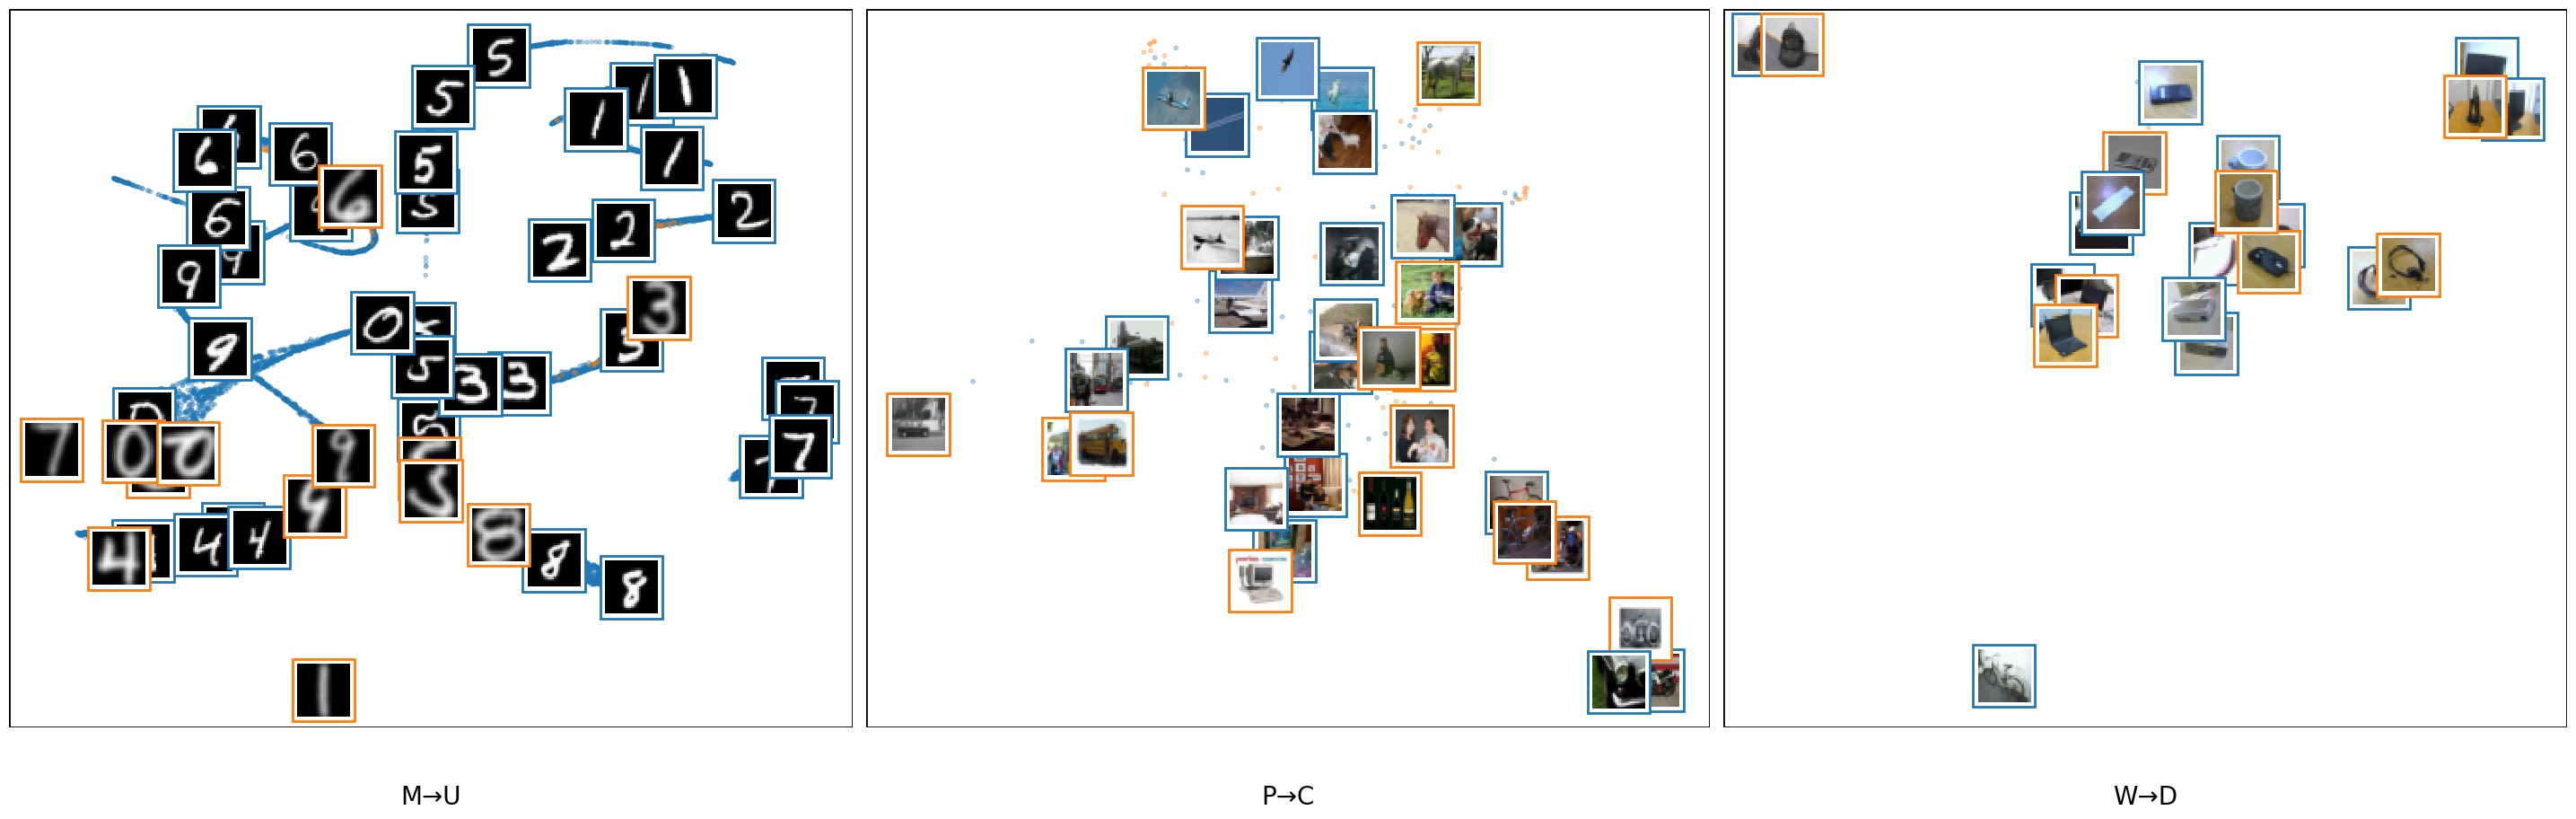

In [33]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
import numpy as np

# Configuración
row_labels = ["M→U", "P→C", "W→D"]
cmap_binary = mpl.colors.ListedColormap(["#ff7f0e", "#1f77b4"])
n_img_per_domain = 60

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))
fig.subplots_adjust(wspace=0)

for i, dataset_key in enumerate(["MNIST-USPS-SVHN", "ImageCLEF", "Office-Caltech"]):
    ax = axes[i]

    try:
        data = creda_results[dataset_key]
        Z = data["Z"]
        is_source = data["is_source"]
        labels_all = data["labels_all"]
        imgs = data["imgs"]
        num_classes = data["num_classes"]

        ax.set_facecolor("white")
        ax.scatter(Z[:, 0], Z[:, 1], c=is_source, cmap=cmap_binary, s=10, alpha=0.3)
        ax.axis("off")

        idx_src = np.where(is_source == 1)[0]
        idx_tgt = np.where(is_source == 0)[0]

        if i in [1, 2]:
            idx_sampled = []
            for cls in range(num_classes):
                cls_src = idx_src[labels_all[idx_src] == cls]
                cls_tgt = idx_tgt[labels_all[idx_tgt] == cls]
                if len(cls_src) >= 2:
                    idx_sampled.extend(np.random.choice(cls_src, 2, replace=False))
                elif len(cls_src) > 0:
                    idx_sampled.extend(np.random.choice(cls_src, 1, replace=False))
                if len(cls_tgt) >= 2:
                    idx_sampled.extend(np.random.choice(cls_tgt, 2, replace=False))
                elif len(cls_tgt) > 0:
                    idx_sampled.extend(np.random.choice(cls_tgt, 1, replace=False))
        else:
            idx_sampled = np.concatenate([
                np.random.choice(idx_src, min(n_img_per_domain, len(idx_src)), replace=False),
                np.random.choice(idx_tgt, min(n_img_per_domain, len(idx_tgt)), replace=False)
            ])

        image_positions = np.array([[10., 10.]])
        for j in idx_sampled:
            pos = Z[j]
            img_array = imgs[j]

            if np.min(np.sum((pos - image_positions)**2, axis=1)) > 0.001:
                image_positions = np.vstack([image_positions, pos])
                ab = AnnotationBbox(
                    OffsetImage(img_array, zoom=1.5, interpolation='nearest'),
                    pos,
                    bboxprops=dict(
                        edgecolor=cmap_binary(is_source[j]),
                        linewidth=2,
                        linestyle='solid'
                    ),
                    frameon=True
                )
                ax.add_artist(ab)

        ax.add_patch(patches.Rectangle((0, 0), 1, 1, transform=ax.transAxes,
                                       linewidth=2, edgecolor='black', facecolor='none'))
        ax.text(0.5, -0.08, row_labels[i],
        transform=ax.transAxes,
        ha='center', va='top',
        fontsize=20)


        if i == 0:
            handles = [
                mpl.patches.Patch(color=cmap_binary(1), label="Source"),
                mpl.patches.Patch(color=cmap_binary(0), label="Target")
            ]


    except Exception as e:
        ax.set_title(f"CREDA Failed", fontsize=10, color="red")
        ax.axis("off")
        print(f"[Error] {dataset_key}: {e}")

plt.tight_layout(rect=[0.03, 0.03, 0.99, 0.95])
plt.savefig("umap_creda_images_row.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [5]:
!pip install torchcam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling nvidia-nvjitlink-cu12-12.9.41:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.9.41
  Attempting uninstall: nvidia-curand-cu12
    Found existing in

/tmp/ipykernel_35/3661493733.py:119: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate(dataset_key,


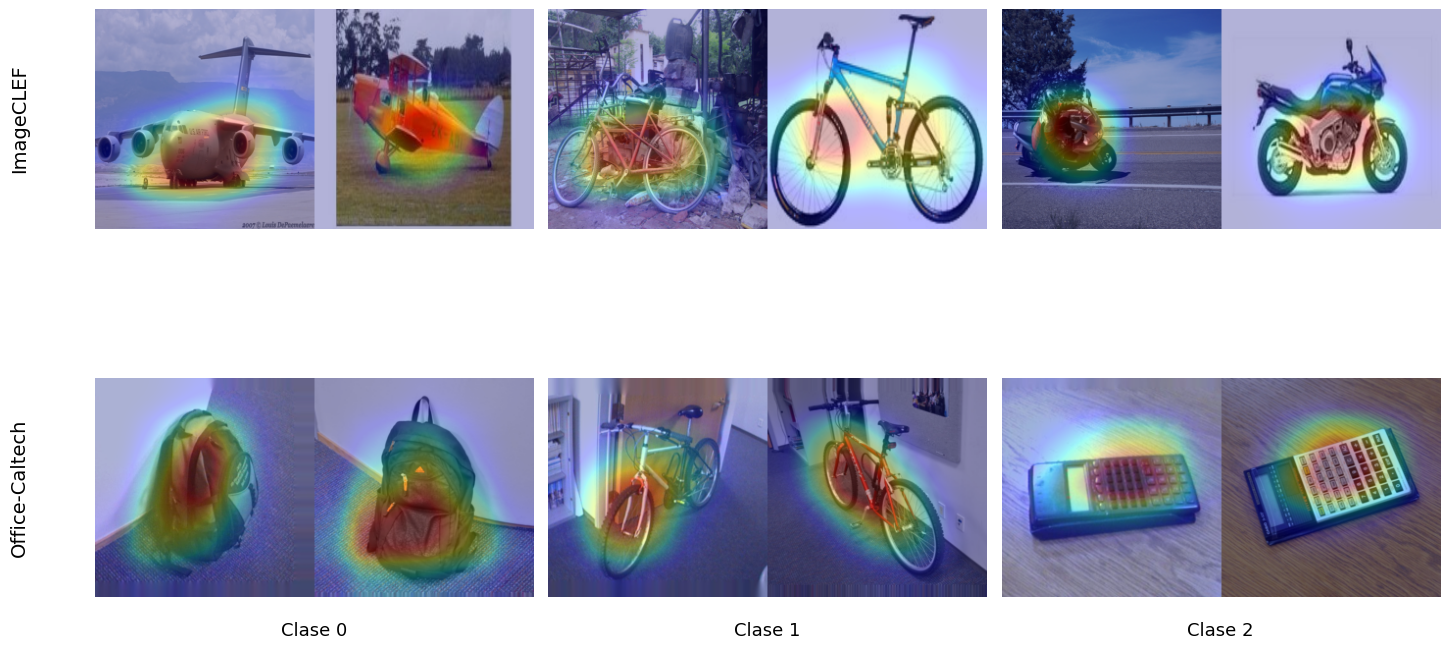

In [34]:
import torch, numpy as np, matplotlib.pyplot as plt
from torch.utils.data import ConcatDataset, DataLoader
from torchvision.transforms.functional import to_pil_image
from torchcam.methods import GradCAMpp
from torchcam.utils import overlay_mask
import matplotlib.patches as patches

# -----------------------------
# CONFIGURACIÓN
# -----------------------------
device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset_names  = ["ImageCLEF", "Office-Caltech"]
n_classes      = 3
batch_size     = 64
index_to_pick  = 0  # <-- Aquí eliges qué imagen quieres por clase: 0 = primera, 1 = segunda, etc.

# -----------------------------
# UTILIDADES
# -----------------------------
def get_last_conv_layer(model):
    return [m for m in model.feature.modules() if isinstance(m, torch.nn.Conv2d)][-1]

def get_denormalizer(dataset_key):
    if dataset_key == "MNIST-USPS-SVHN":
        mean, std = [0.5]*3, [0.5]*3
    else:
        mean = [0.485, 0.456, 0.406]
        std  = [0.229, 0.224, 0.225]
    def denorm(t):
        for ch, m, s in zip(t, mean, std):
            ch.mul_(s).add_(m)
        return t.clamp(0, 1)
    return denorm

def norm_cam(cam):
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam

def get_nth_image_for_class(dataloader, class_idx, index, device):
    """Devuelve la imagen N-ésima (index) de clase `class_idx` encontrada en el dataloader."""
    imgs = []
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        mask = (y == class_idx)
        if mask.any():
            imgs.extend(x[mask].detach().cpu())
        if len(imgs) > index:
            return imgs[index]
    return None  # No hay suficientes imágenes de esa clase

# -----------------------------
# FIGURA
# -----------------------------
fig, axes = plt.subplots(nrows=len(dataset_names), ncols=n_classes, figsize=(15, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for row_idx, dataset_key in enumerate(dataset_names):
    sets_dict           = sets_all[dataset_key]
    src_key, tgt_key    = combinations_dict[dataset_key]
    src_data, tgt_data  = sets_dict[src_key], sets_dict[tgt_key]

    src_train, src_val, src_test = split_stratified(src_data, 0.15, 0.15)
    tgt_train, tgt_val, tgt_test = split_stratified(tgt_data, 0.15, 0.15)
    src_test = ConcatDataset([src_val, src_test])
    tgt_test = ConcatDataset([tgt_val, tgt_test])

    src_loader = DataLoader(src_test, batch_size=batch_size, shuffle=False)
    tgt_loader = DataLoader(tgt_test, batch_size=batch_size, shuffle=False)

    targets = src_data.targets if hasattr(src_data, 'targets') else src_data.labels
    num_classes = len(set(targets.tolist() if hasattr(targets, 'tolist') else list(targets)))

    model = load_model("creda", src_key, tgt_key,
                       path="/kaggle/input/model-ad/Models",
                       num_classes=num_classes).eval().to(device)

    cam_extractor = GradCAMpp(model, target_layer=get_last_conv_layer(model))
    denormalize   = get_denormalizer(dataset_key)

    for class_idx in range(n_classes):
        ax = axes[row_idx, class_idx]

        img_src = get_nth_image_for_class(src_loader, class_idx, index=index_to_pick, device=device)
        img_tgt = get_nth_image_for_class(tgt_loader, class_idx, index=index_to_pick, device=device)

        if img_src is None or img_tgt is None:
            ax.set_title(f"No data", color='red')
            ax.axis("off")
            continue

        cam_src = cam_extractor(class_idx, model(img_src.unsqueeze(0).to(device)))[0].cpu()
        cam_tgt = cam_extractor(class_idx, model(img_tgt.unsqueeze(0).to(device)))[0].cpu()
        cam_src, cam_tgt = norm_cam(cam_src), norm_cam(cam_tgt)

        img_src_denorm = denormalize(img_src.clone())
        img_tgt_denorm = denormalize(img_tgt.clone())

        overlay_src = overlay_mask(to_pil_image(img_src_denorm),
                                   to_pil_image(cam_src, mode='F'),
                                   alpha=0.7)
        overlay_tgt = overlay_mask(to_pil_image(img_tgt_denorm),
                                   to_pil_image(cam_tgt, mode='F'),
                                   alpha=0.7)

        ax.imshow(np.hstack([np.array(overlay_src), np.array(overlay_tgt)]))
        ax.axis("off")

        # Etiqueta de clase debajo solo en la última fila
        if row_idx == len(dataset_names) - 1:
            ax.text(0.5, -0.15, f"Clase {class_idx}",
                    transform=ax.transAxes,
                    ha='center', va='center',
                    fontsize=13)

# Etiquetas del dataset a la izquierda
for row_idx, dataset_key in enumerate(dataset_names):
    ax = axes[row_idx, 0]
    ax.annotate(dataset_key,
                xy=(-0.15, 0.5), xycoords='axes fraction',
                textcoords='offset points',
                ha='right', va='center',
                fontsize=14, rotation=90)

plt.tight_layout(rect=[0.03, 0.03, 0.99, 0.95])
plt.savefig("Cams.pdf", format="pdf", bbox_inches="tight")
plt.show()
